Imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

Read in the AR event type dataset provided by Joe Riedl and Dr. Paul Loikith

In [5]:
df = pd.read_csv('C:\\Users\\Tony\\Documents\\GitHub\EAE-598-Project\\ar_event_type.csv')
df

,Event Start,Event Dur,maxScale,maxLocDur,maxIVT,maxIVTLat,maxScaletime,Type
0,2009101306,120,5,108,1007,37,2009101306,Ncyc
1,2009102300,18,1,18,689,48,2009102306,Ncyc
2,2009102518,12,1,12,574,47,2009102518,Ncyc
3,2009102806,78,2,42,731,48,2009102912,Scyc
4,2009110506,24,2,24,640,44,2009110506,Ncyc
...,...,...,...,...,...,...,...,...
248,2019022418,78,3,54,708,37,2019022600,NDcyc
249,2019030112,24,1,24,513,35,2019030118,Ncyc
250,2019040506,60,3,60,731,44,2019040506,NDcyc
251,2019041806,24,2,24,508,47,2019041806,Ncyc


Convert the Event Start column to a Pandas datetime object

In [6]:
df['start_date'] = pd.to_datetime(df['Event Start'], format='%Y%m%d%H')
df

,Event Start,Event Dur,maxScale,maxLocDur,maxIVT,maxIVTLat,maxScaletime,Type,start_date
0,2009101306,120,5,108,1007,37,2009101306,Ncyc,2009-10-13 06:00:00
1,2009102300,18,1,18,689,48,2009102306,Ncyc,2009-10-23 00:00:00
2,2009102518,12,1,12,574,47,2009102518,Ncyc,2009-10-25 18:00:00
3,2009102806,78,2,42,731,48,2009102912,Scyc,2009-10-28 06:00:00
4,2009110506,24,2,24,640,44,2009110506,Ncyc,2009-11-05 06:00:00
...,...,...,...,...,...,...,...,...,...
248,2019022418,78,3,54,708,37,2019022600,NDcyc,2019-02-24 18:00:00
249,2019030112,24,1,24,513,35,2019030118,Ncyc,2019-03-01 12:00:00
250,2019040506,60,3,60,731,44,2019040506,NDcyc,2019-04-05 06:00:00
251,2019041806,24,2,24,508,47,2019041806,Ncyc,2019-04-18 06:00:00


Add a water year column

In [15]:
water_years = []

for i in df['start_date']:
    if i.month < 10:
        water_years.append(i.year)
    else:
        water_years.append(i.year + 1)

df['water_year'] = water_years
df

,Event Start,Event Dur,maxScale,maxLocDur,maxIVT,maxIVTLat,maxScaletime,Type,start_date,water_year
0,2009101306,120,5,108,1007,37,2009101306,Ncyc,2009-10-13 06:00:00,2010
1,2009102300,18,1,18,689,48,2009102306,Ncyc,2009-10-23 00:00:00,2010
2,2009102518,12,1,12,574,47,2009102518,Ncyc,2009-10-25 18:00:00,2010
3,2009102806,78,2,42,731,48,2009102912,Scyc,2009-10-28 06:00:00,2010
4,2009110506,24,2,24,640,44,2009110506,Ncyc,2009-11-05 06:00:00,2010
...,...,...,...,...,...,...,...,...,...,...
248,2019022418,78,3,54,708,37,2019022600,NDcyc,2019-02-24 18:00:00,2019
249,2019030112,24,1,24,513,35,2019030118,Ncyc,2019-03-01 12:00:00,2019
250,2019040506,60,3,60,731,44,2019040506,NDcyc,2019-04-05 06:00:00,2019
251,2019041806,24,2,24,508,47,2019041806,Ncyc,2019-04-18 06:00:00,2019


Determine the frequency of AR events per water year

In [24]:
ar_counts = df['water_year'].value_counts()
ar_counts

2017    34
2010    28
2012    28
2019    27
2011    26
2018    25
2015    24
2016    24
2013    23
2014    14
Name: water_year, dtype: int64

Need to sort by index so it goes from the oldest date to the most recent date

In [ ]:
ar_counts = ar_counts.sort_index()
ar_counts

2010    28
2011    26
2012    28
2013    23
2014    14
2015    24
2016    24
2017    34
2018    25
2019    27
Name: water_year, dtype: int64

Let's calculate the average number of events per year

In [33]:
average_ar_events = ar_counts.mean()
average_ar_events

25.3

Let's plot it!

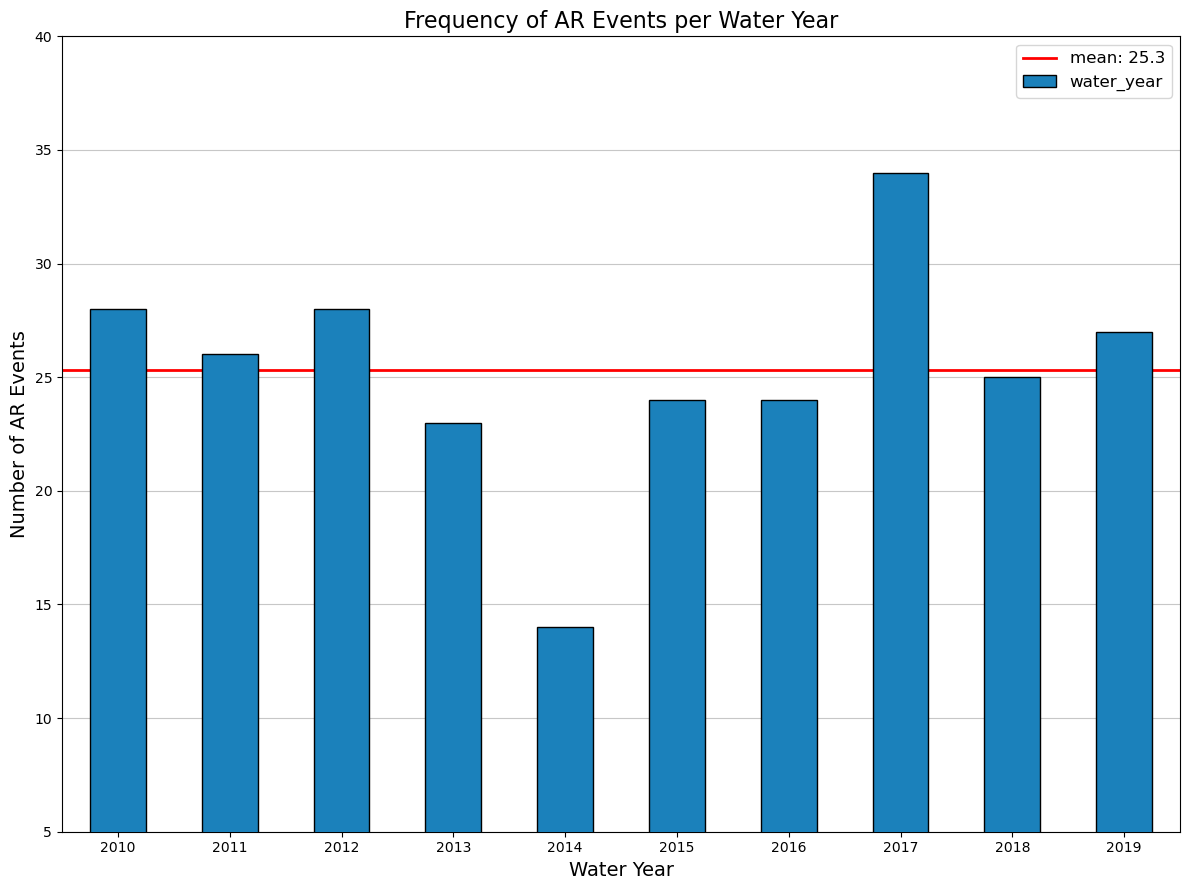

In [104]:
plt.figure(figsize=(12, 9))
ar_counts.plot(kind='bar', color='#1b81bb', edgecolor='black', zorder=99)
plt.axhline(y=average_ar_events, color='red', linestyle='-', linewidth=2, label=f'mean: {average_ar_events:.1f}', zorder=1)

plt.ylim(5, 40)
plt.title('Frequency of AR Events per Water Year', fontsize=16)
plt.xlabel('Water Year', fontsize=14)
plt.ylabel('Number of AR Events', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.7, zorder=0)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

Now let's do the same thing, but this time with the number of AR events that are >= Category 2

In [48]:
df_cat2 = df[df['maxScale'] >= 2]
df_cat2

,Event Start,Event Dur,maxScale,maxLocDur,maxIVT,maxIVTLat,maxScaletime,Type,start_date,water_year
0,2009101306,120,5,108,1007,37,2009101306,Ncyc,2009-10-13 06:00:00,2010
3,2009102806,78,2,42,731,48,2009102912,Scyc,2009-10-28 06:00:00,2010
4,2009110506,24,2,24,640,44,2009110506,Ncyc,2009-11-05 06:00:00,2010
6,2009111506,60,3,42,922,46,2009111512,Ncyc,2009-11-15 06:00:00,2010
7,2009111900,42,2,36,672,46,2009111900,NDcyc,2009-11-19 00:00:00,2010
...,...,...,...,...,...,...,...,...,...,...
246,2019020106,96,3,60,726,36,2019020200,Ncyc,2019-02-01 06:00:00,2019
247,2019021300,48,4,42,1075,33,2019021306,Scyc,2019-02-13 00:00:00,2019
248,2019022418,78,3,54,708,37,2019022600,NDcyc,2019-02-24 18:00:00,2019
250,2019040506,60,3,60,731,44,2019040506,NDcyc,2019-04-05 06:00:00,2019


In [50]:
ar2_counts = df_cat2['water_year'].value_counts().sort_index()
ar2_counts

2010    17
2011    17
2012    14
2013     9
2014     8
2015    15
2016    16
2017    27
2018    15
2019    17
Name: water_year, dtype: int64

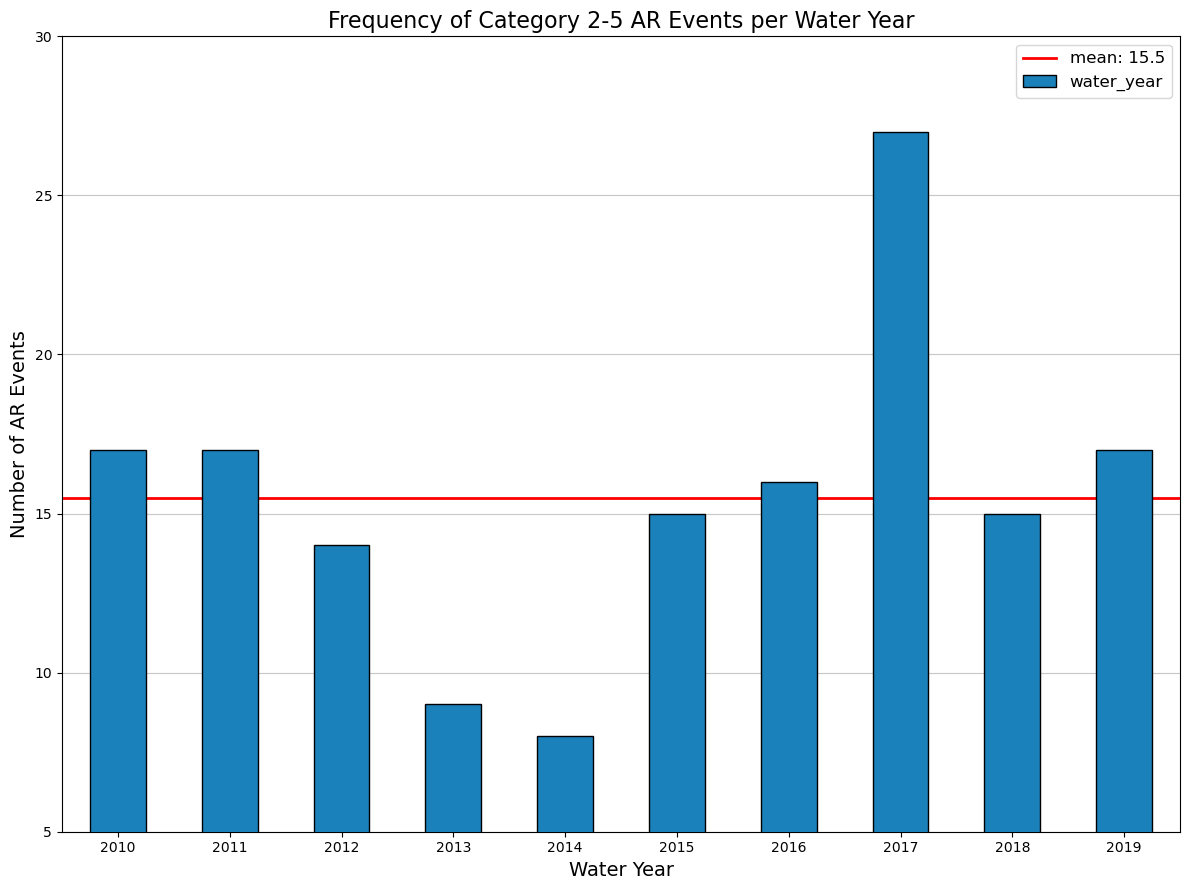

In [103]:
average_ar2_events = ar2_counts.mean()

plt.figure(figsize=(12, 9))
ar2_counts.plot(kind='bar', color='#1b81bb', edgecolor='black', zorder=99)
plt.axhline(y=average_ar2_events, color='red', linestyle='-', linewidth=2, label=f'mean: {average_ar2_events:.1f}', zorder=1)

plt.ylim(5, 30)
plt.title('Frequency of Category 2-5 AR Events per Water Year', fontsize=16)
plt.xlabel('Water Year', fontsize=14)
plt.ylabel('Number of AR Events', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.7, zorder=0)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

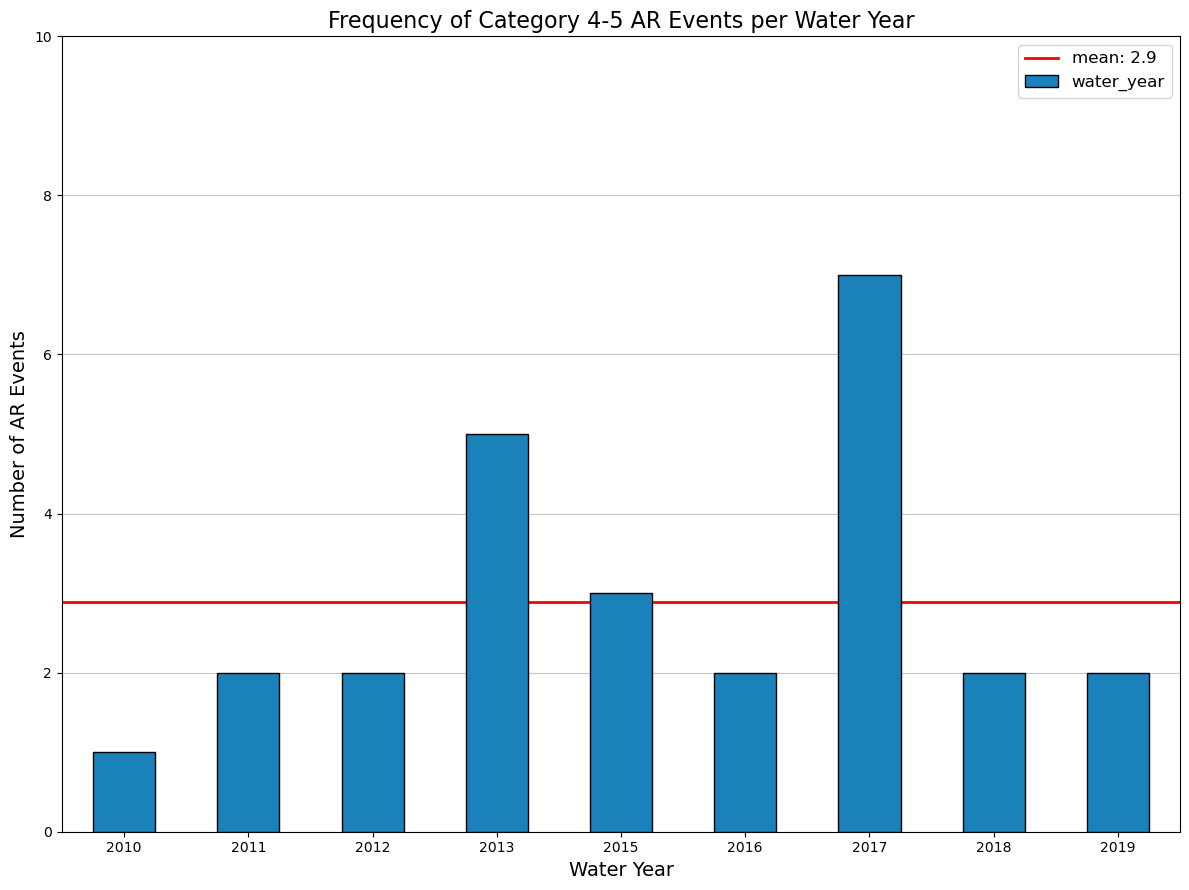

In [102]:
df_cat4 = df[df['maxScale'] >= 4]
ar4_counts = df_cat4['water_year'].value_counts().sort_index()
average_ar4_events = ar4_counts.mean()

plt.figure(figsize=(12, 9))
ar4_counts.plot(kind='bar', color='#1b81bb', edgecolor='black', zorder=99)
plt.axhline(y=average_ar4_events, color='red', linestyle='-', linewidth=2, label=f'mean: {average_ar4_events:.1f}', zorder=1)

plt.ylim(0, 10)
plt.title('Frequency of Category 4-5 AR Events per Water Year', fontsize=16)
plt.xlabel('Water Year', fontsize=14)
plt.ylabel('Number of AR Events', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.7, zorder=0)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

What about the frequency of these events per month rather than per water year?

In [118]:
df['month'] = df['start_date'].dt.month
df['month']

0      10
1      10
2      10
3      10
4      11
       ..
248     2
249     3
250     4
251     4
252     4
Name: month, Length: 253, dtype: int64

In [121]:
ar_monthly_counts = df['month'].value_counts()
ar_monthly_counts

11    46
1     42
10    38
3     38
12    36
2     30
4     23
Name: month, dtype: int64

Need to add months without AR events

In [122]:
ar_monthly_counts = df['month'].value_counts().reindex(range(1, 13), fill_value=0)
ar_monthly_counts

1     42
2     30
3     38
4     23
5      0
6      0
7      0
8      0
9      0
10    38
11    46
12    36
Name: month, dtype: int64

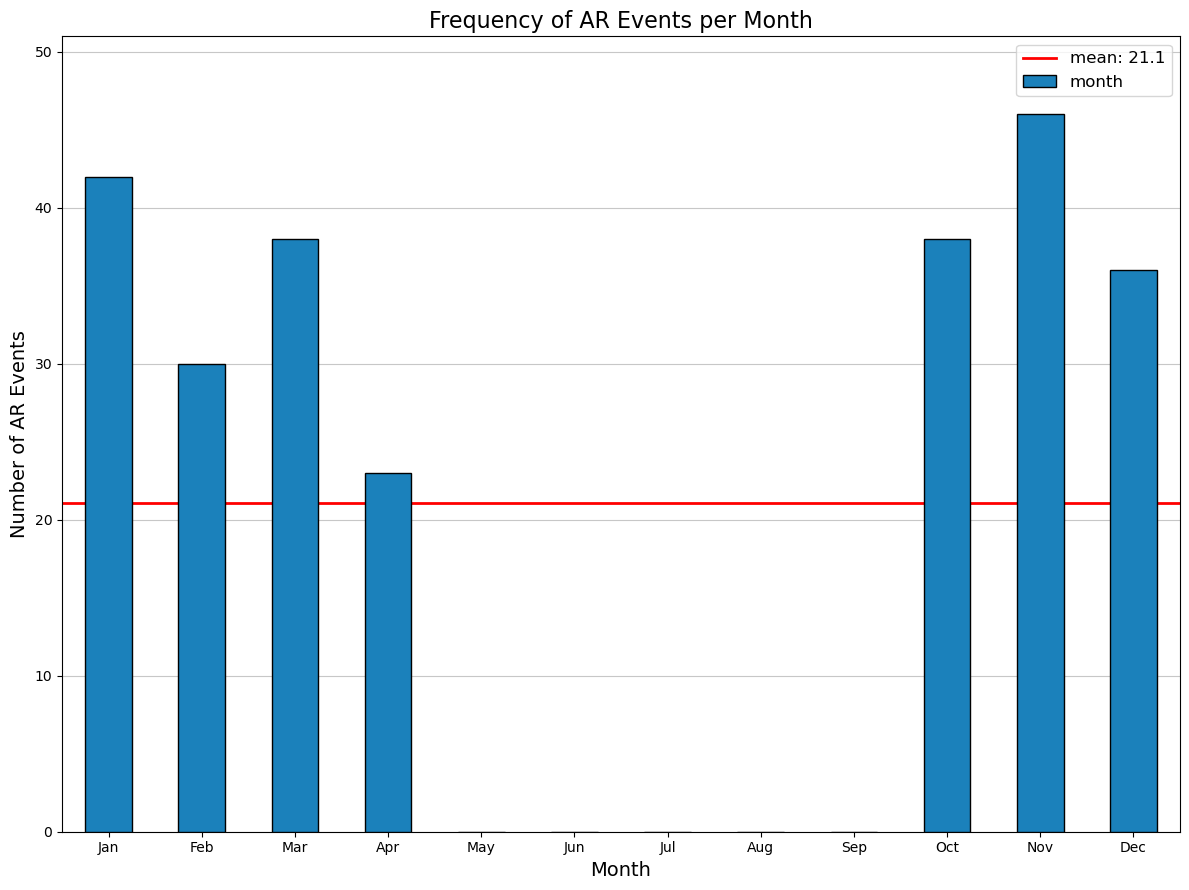

In [123]:
average_ar_monthly_events = ar_monthly_counts.mean()

plt.figure(figsize=(12, 9))
ar_monthly_counts.plot(kind='bar', color='#1b81bb', edgecolor='black', zorder=99)
plt.axhline(y=average_ar_monthly_events, color='red', linestyle='-', linewidth=2, label=f'mean: {average_ar_monthly_events:.1f}', zorder=1)

plt.ylim(0, ar_monthly_counts.max() + 5)
plt.title('Frequency of AR Events per Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of AR Events', fontsize=14)
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
plt.grid(axis='y', alpha=0.7, zorder=0)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

May-Sep seems a bit strange - let's do some digging

In [127]:
for i in df['start_date']:
    if (i.month == 5) or (i.month == 6) or (i.month == 7) or (i.month == 8) or (i.month == 9):
        print(i.year, i.month, i.day, i.hour)

So it did not print anything, let's check the other months

In [128]:
for i in df['start_date']:
    if (i.month < 5) or (i.month > 9):
        print(i.year, i.month, i.day, i.hour)

2009 10 13 6
2009 10 23 0
2009 10 25 18
2009 10 28 6
2009 11 5 6
2009 11 9 6
2009 11 15 6
2009 11 19 0
2009 11 22 0
2009 11 25 0
2009 12 7 18
2009 12 15 0
2009 12 20 12
2009 12 30 0
2010 1 10 18
2010 1 14 18
2010 1 17 12
2010 1 20 12
2010 1 24 12
2010 2 4 12
2010 2 11 6
2010 2 13 12
2010 2 24 0
2010 2 26 0
2010 3 11 6
2010 3 14 18
2010 3 28 0
2010 4 26 18
2010 10 3 0
2010 10 9 0
2010 10 23 0
2010 10 28 0
2010 10 31 0
2010 11 6 18
2010 11 18 0
2010 11 30 0
2010 12 6 0
2010 12 7 0
2010 12 11 6
2010 12 14 6
2010 12 17 12
2010 12 23 12
2011 1 12 12
2011 2 3 12
2011 2 12 0
2011 2 14 6
2011 2 18 12
2011 3 1 6
2011 3 5 6
2011 3 9 6
2011 3 13 6
2011 3 20 18
2011 3 29 6
2011 4 14 12
2011 10 1 0
2011 10 2 18
2011 10 21 18
2011 10 28 12
2011 10 30 6
2011 11 11 12
2011 11 12 6
2011 11 16 18
2011 11 22 0
2011 11 26 6
2011 12 27 18
2012 1 3 18
2012 1 18 0
2012 1 24 12
2012 1 29 0
2012 2 8 12
2012 2 21 6
2012 3 9 6
2012 3 12 6
2012 3 21 0
2012 3 27 0
2012 3 29 0
2012 4 2 12
2012 4 8 6
2012 4 18 0
201

It appears that this dataset did not have any AR events from May - Sep

Now let's see the type of AR events, such as those with MFWs and SCYCs

In [62]:
scyc_counts = df[df['Type'] == 'Scyc'].groupby('water_year').size()
ndcyc_counts = df[df['Type'] == 'NDcyc'].groupby('water_year').size()
ncyc_counts = df[df['Type'] == 'Ncyc'].groupby('water_year').size()

In [93]:
print(scyc_counts)
print(ndcyc_counts)
print(ncyc_counts)

water_year
2010    4
2011    6
2012    6
2013    2
2014    3
2015    8
2016    3
2017    8
2018    4
2019    4
dtype: int64
water_year
2010     8
2011     6
2012     2
2013     7
2014     2
2015     4
2016    10
2017     9
2018     3
2019     4
dtype: int64
water_year
2010    16
2011    14
2012    20
2013    14
2014     9
2015    12
2016    11
2017    17
2018    17
2019    19
dtype: int64


Let's plot it!

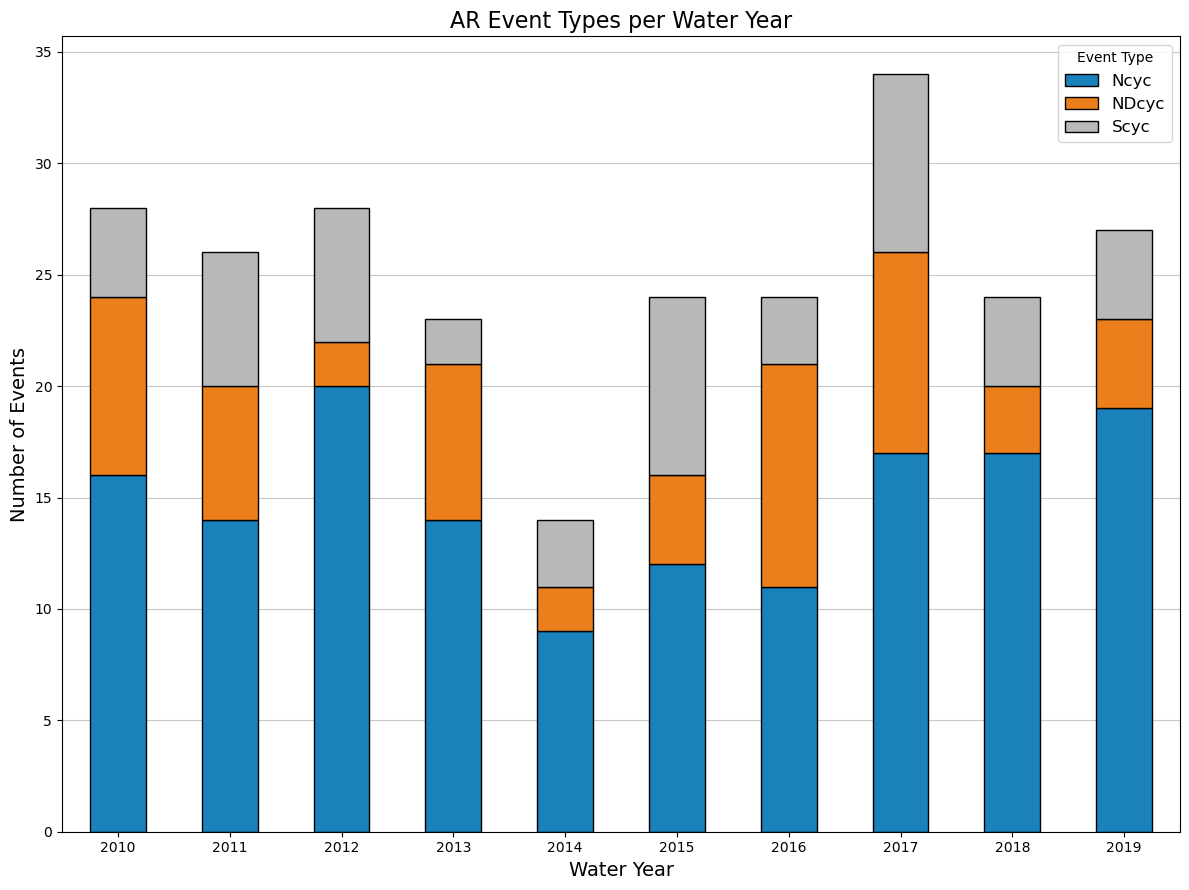

In [98]:
bar_df = pd.DataFrame({
    'Ncyc': ncyc_counts,
    'NDcyc': ndcyc_counts,
    'Scyc': scyc_counts})

bar_df.plot(kind='bar', stacked=True, figsize=(12, 9), color=['#1b81bb', '#ea7f1b', '#b8b8b8'], edgecolor='black', zorder=2)

plt.title('AR Event Types per Water Year', fontsize=16)
plt.xlabel('Water Year', fontsize=14)
plt.ylabel('Number of Events', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Event Type', fontsize=12)
plt.grid(axis='y', linestyle='-', alpha=0.7, zorder=1)
plt.tight_layout()
plt.show()

Let's do the same but for each month rather than water year

In [132]:
scyc_counts = df[df['Type'] == 'Scyc'].groupby('month').size()
ndcyc_counts = df[df['Type'] == 'NDcyc'].groupby('month').size()
ncyc_counts = df[df['Type'] == 'Ncyc'].groupby('month').size()

scyc_counts = scyc_counts.reindex(range(1, 13), fill_value=0)
ndcyc_counts = ndcyc_counts.reindex(range(1, 13), fill_value=0)
ncyc_counts = ncyc_counts.reindex(range(1, 13), fill_value=0)

print(scyc_counts)
print(ndcyc_counts)
print(ncyc_counts)

month
1      5
2      8
3      8
4      4
5      0
6      0
7      0
8      0
9      0
10    10
11     7
12     6
dtype: int64
month
1     14
2      6
3      5
4      4
5      0
6      0
7      0
8      0
9      0
10     8
11     9
12     9
dtype: int64
month
1     23
2     16
3     25
4     15
5      0
6      0
7      0
8      0
9      0
10    20
11    29
12    21
dtype: int64


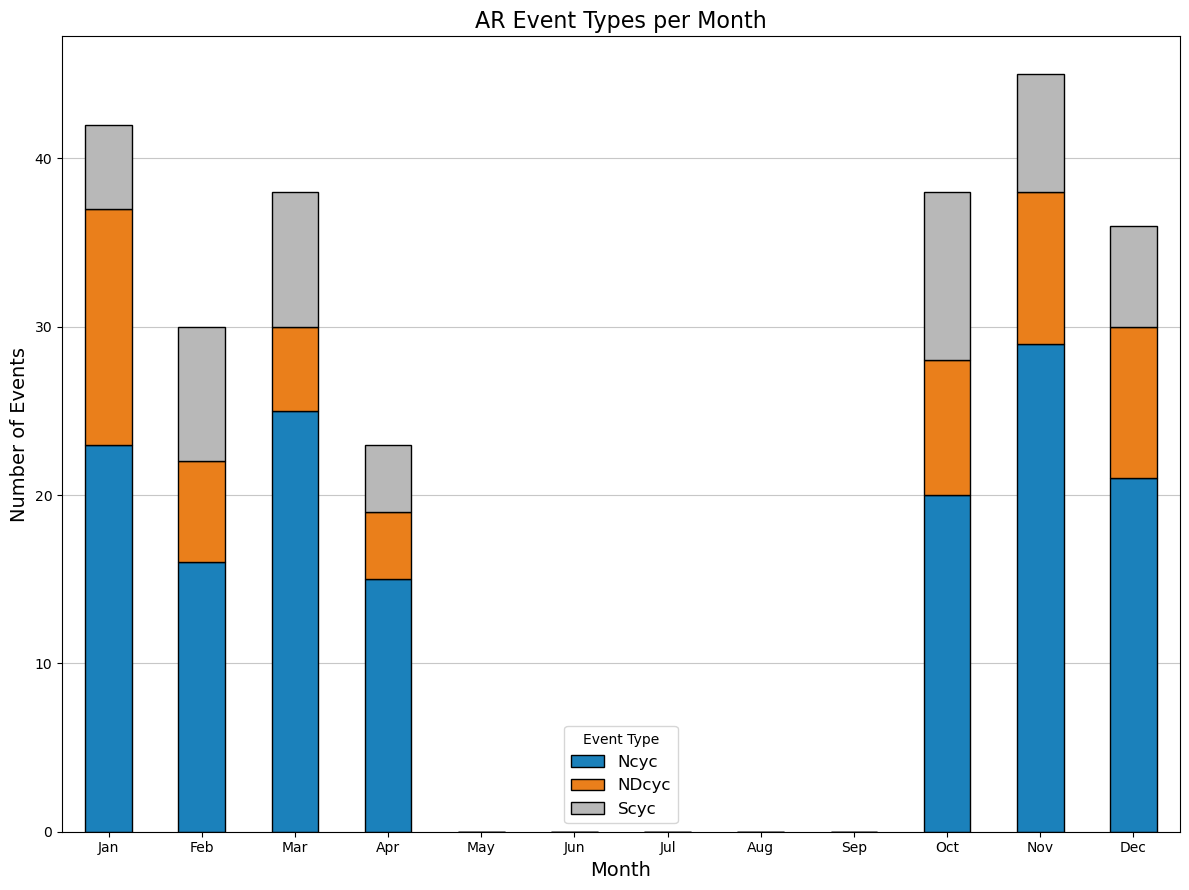

In [135]:
bar_df = pd.DataFrame({
    'Ncyc': ncyc_counts,
    'NDcyc': ndcyc_counts,
    'Scyc': scyc_counts})

bar_df.plot(kind='bar', stacked=True, figsize=(12, 9), color=['#1b81bb', '#ea7f1b', '#b8b8b8'], edgecolor='black', zorder=2)

plt.title('AR Event Types per Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Events', fontsize=14)
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
plt.legend(title='Event Type', fontsize=12, loc='best')
plt.grid(axis='y', linestyle='-', alpha=0.7, zorder=1)
plt.tight_layout()
plt.show()

Now let's compare the number of AR events with and without MFWs (i.e., ML labels)

In [ ]:
total_events = len(df)
print(f'Total number of events: {total_events}')

total_ndcyc_events = len(df[df['Type'] == 'NDcyc'])
print(f'Total number of NDcyc events: {total_ndcyc_events}')

Total number of events: 253
Total number of NDcyc events: 55


Let's plot it

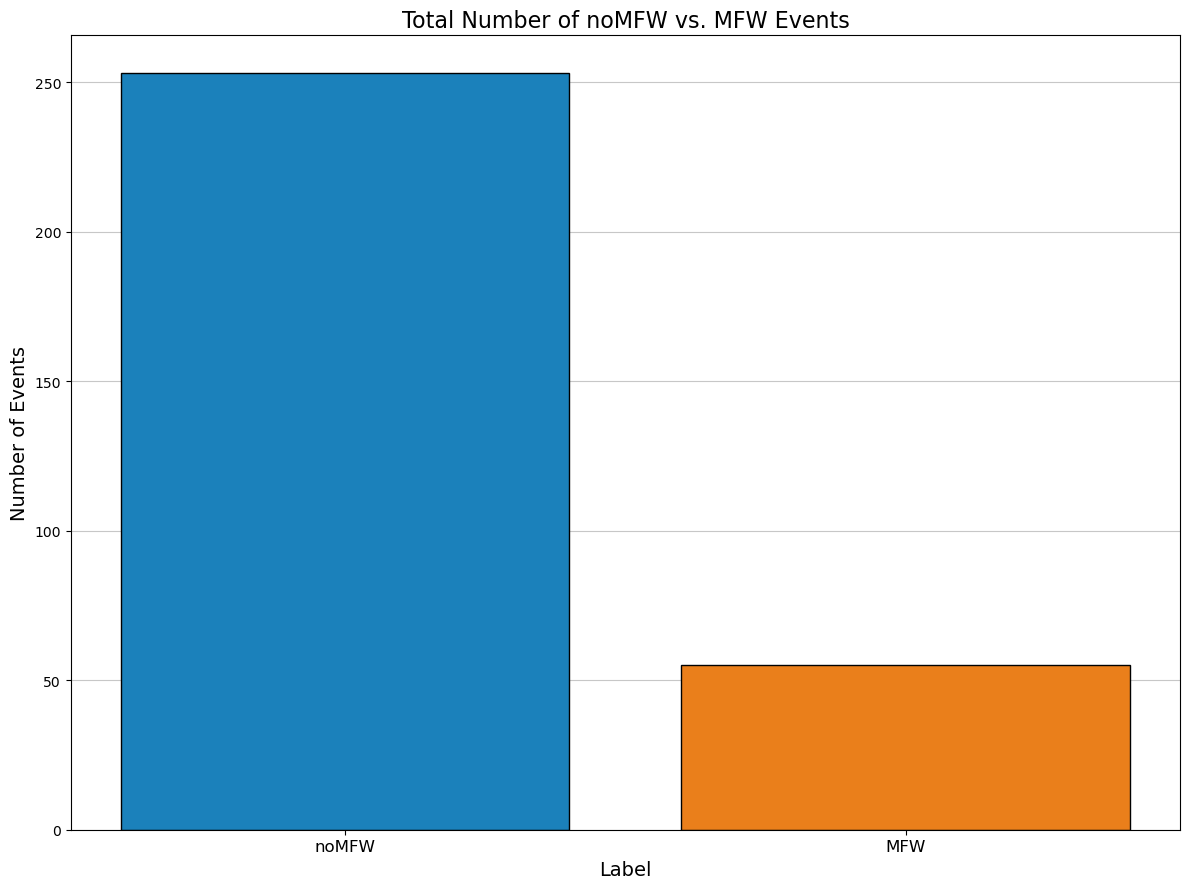

In [97]:
plt.figure(figsize=(12, 9))
plt.bar(['noMFW', 'MFW'], [total_events, total_ndcyc_events], color=['#1b81bb', '#ea7f1b'], edgecolor='black', zorder=2)

plt.title('Total Number of noMFW vs. MFW Events', fontsize=16)
plt.xlabel("Label", fontsize=14)
plt.ylabel('Number of Events', fontsize=14)
plt.xticks(fontsize=12)
plt.grid(axis='y', linestyle='-', alpha=0.7, zorder=1)
plt.tight_layout()
plt.show()